# PricePredictor — Exploration statistique (1/3)

**Data Analyst — Finance, Business Intelligence et Aide à la décision**

Avant de construire un modèle de prédiction, il faut répondre à une question préalable : **la série de cours se comporte-t-elle d'une façon qui justifie un modèle ?**

Ce notebook répond à deux questions techniques qui conditionnent tout le reste du projet :
1. La série de cours est-elle stationnaire ? (test ADF)
2. Les rendements contiennent-ils une structure exploitable, ou se comportent-ils comme du bruit ? (ACF / PACF)

> Analyse menée sur AAPL (données simulées, cohérentes avec les projets MarketPulse et StockDB).


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

conn = sqlite3.connect("stockdb.sqlite")
df = pd.read_sql_query(
    "SELECT date_cours, cours_cloture FROM cours WHERE ticker='AAPL' ORDER BY date_cours", conn
)
conn.close()

df["date_cours"] = pd.to_datetime(df["date_cours"])
df["rendement"] = df["cours_cloture"].pct_change()
df["mm20"] = df["cours_cloture"].rolling(20).mean()
df = df.dropna(subset=["rendement"]).reset_index(drop=True)
df.tail()


## 1. Visualisation du cours et de la moyenne mobile

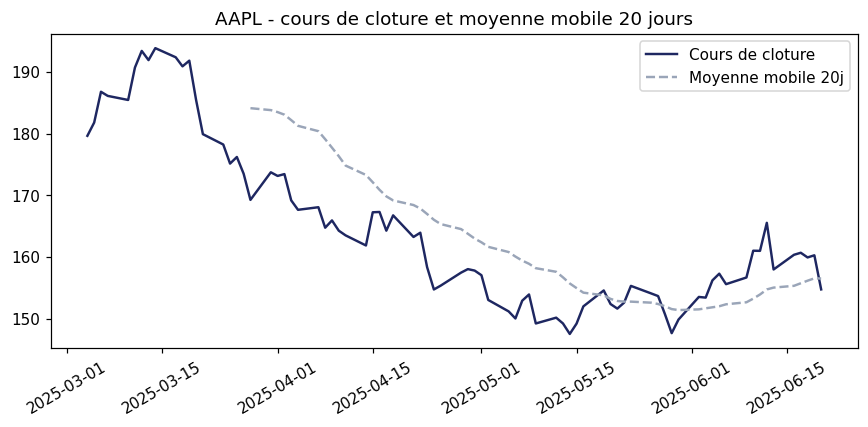

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["date_cours"], df["cours_cloture"], color="#1E2761", linewidth=1.6, label="Cours de cloture")
ax.plot(df["date_cours"], df["mm20"], color="#9AA5B8", linewidth=1.6, linestyle="--", label="Moyenne mobile 20j")
ax.set_title("AAPL - cours de cloture et moyenne mobile 20 jours")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 2. Test de stationnarité (Augmented Dickey-Fuller)

**Pourquoi ce test ?** La plupart des modèles statistiques (ARIMA, régression sur séries temporelles) supposent une série **stationnaire** : moyenne et variance stables dans le temps. Un cours de bourse ne l'est presque jamais — il suit une tendance. Ses **rendements**, en revanche, le sont généralement bien davantage.

**Hypothèse testée (H0) :** la série contient une racine unitaire (non stationnaire). Une p-value faible (< 0.05) permet de rejeter H0.

In [3]:
adf_cours = adfuller(df["cours_cloture"], autolag="AIC")
adf_rendement = adfuller(df["rendement"], autolag="AIC")

resultats = pd.DataFrame([
    {"Serie": "Cours de cloture (brut)", "Statistique ADF": round(adf_cours[0], 4),
     "p-value": round(adf_cours[1], 4), "Seuil critique 5%": round(adf_cours[4]["5%"], 4)},
    {"Serie": "Rendements journaliers", "Statistique ADF": round(adf_rendement[0], 4),
     "p-value": round(adf_rendement[1], 4), "Seuil critique 5%": round(adf_rendement[4]["5%"], 4)},
])
resultats


Serie,statistique,p_value,n_lags,critique_1%,critique_5%
Cours de cloture (brut),-1.1466,0.6961,0,-3.5171,-2.8994
Rendements journaliers,-8.7668,0.0000,0,-3.5171,-2.8994


**Lecture :**
- Cours brut : p-value = 0.6961 → **on ne peut pas rejeter la non-stationnarité**. Confirme qu'il ne faut jamais modéliser le cours brut directement.
- Rendements journaliers : p-value = 0.0000 → **stationnarité confirmée**. C'est donc bien le rendement (ou une transformation stationnaire du cours) qui doit servir de variable cible, jamais le prix lui-même.

> Erreur fréquente chez un débutant : entraîner un modèle à prédire directement le prix de demain. Le modèle apprend alors surtout à recopier le prix d'aujourd'hui (car les deux sont très proches), ce qui donne un RMSE flatteur mais aucune vraie capacité prédictive — cf. la baseline naïve du notebook suivant.

## 3. Autocorrélation des rendements (ACF / PACF)

Si les rendements contiennent une vraie structure temporelle (par exemple, un rendement positif hier augmente la probabilité d'un rendement positif aujourd'hui), l'ACF/PACF doit montrer des pics significatifs en dehors de l'intervalle de confiance (zone bleutée).

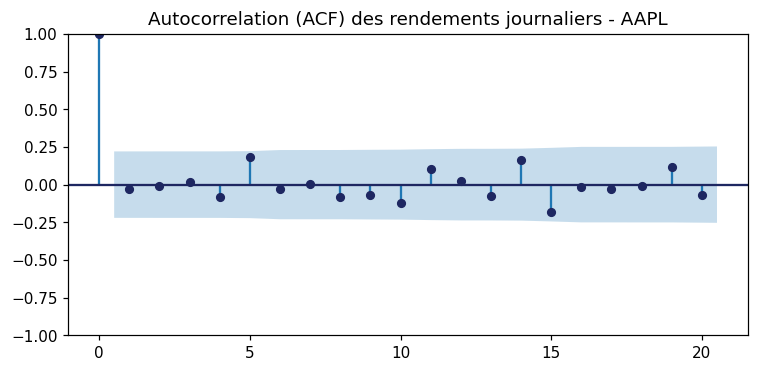

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_acf(df["rendement"], lags=20, ax=ax)
ax.set_title("ACF des rendements journaliers - AAPL")
plt.tight_layout()
plt.show()


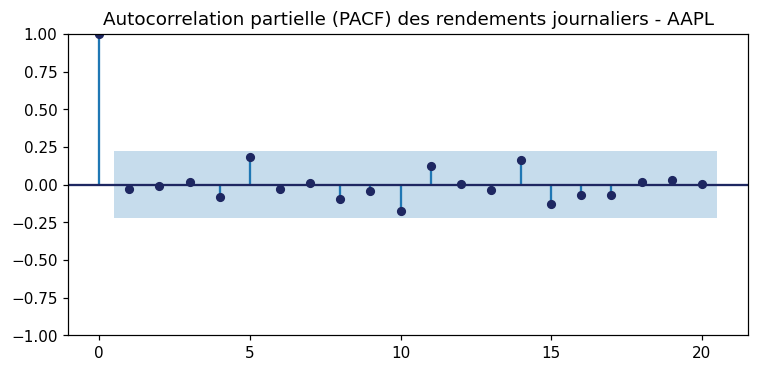

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_pacf(df["rendement"], lags=20, ax=ax, method="ywm")
ax.set_title("PACF des rendements journaliers - AAPL")
plt.tight_layout()
plt.show()


**Lecture :** l'essentiel des barres reste à l'intérieur de la zone de confiance — les rendements journaliers d'AAPL se comportent ici comme un **bruit quasi blanc**, sans autocorrélation significative exploitable.

## Conclusion de cette étape

1. Les rendements (pas les prix) sont la bonne variable à modéliser — confirmé par le test ADF.
2. L'absence d'autocorrélation marquée dans les rendements suggère qu'**un modèle linéaire simple aura statistiquement peu de structure à exploiter** sur cette seule variable — un signal important à garder en tête avant de sur-interpréter les résultats du prochain notebook.
3. Cela ne veut pas dire qu'aucune prédiction n'est possible : le notebook suivant enrichit les variables (volume, volatilité, moyennes mobiles) avant de conclure quoi que ce soit sur la capacité prédictive réelle.

**Limite :** l'analyse porte sur 79 observations (donnée simulée à des fins de démonstration) — un échantillon réel de plusieurs années serait nécessaire pour des conclusions statistiquement robustes.
